In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.image as mpimg
import cv2
from PIL import Image 
from  sklearn.model_selection import train_test_split
import numpy as np

In [2]:
base_path = r'D:\csv\archive (1)\data'

print(os.listdir(base_path))


['without_mask', 'with_mask']


In [3]:
with_mask_files = os.listdir(r'D:\csv\archive (1)\data\with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']
['with_mask_995.jpg', 'with_mask_996.jpg', 'with_mask_997.jpg', 'with_mask_998.jpg', 'with_mask_999.jpg']


In [4]:
without_mask_files = os.listdir(r"D:\csv\archive (1)\data\without_mask")
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_995.jpg', 'without_mask_996.jpg', 'without_mask_997.jpg', 'without_mask_998.jpg', 'without_mask_999.jpg']


In [5]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


In [6]:
without_mask_path = os.path.join(base_path, 'without_mask')

print("Without Mask Images:", len(os.listdir(without_mask_path)))


Without Mask Images: 3828


In [7]:
without_mask_path = os.listdir(without_mask_path)

In [8]:
print(without_mask_path[0:5])
print(without_mask_path[0:-5])

['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg', 'without_mask_1002.jpg', 'without_mask_1003.jpg', 'without_mask_1004.jpg', 'without_mask_1005.jpg', 'without_mask_1006.jpg', 'without_mask_1007.jpg', 'without_mask_1008.jpg', 'without_mask_1009.jpg', 'without_mask_101.jpg', 'without_mask_1010.jpg', 'without_mask_1011.jpg', 'without_mask_1012.jpg', 'without_mask_1013.jpg', 'without_mask_1014.jpg', 'without_mask_1015.jpg', 'without_mask_1016.jpg', 'without_mask_1017.jpg', 'without_mask_1018.jpg', 'without_mask_1019.jpg', 'without_mask_102.jpg', 'without_mask_1020.jpg', 'without_mask_1021.jpg', 'without_mask_1022.jpg', 'without_mask_1023.jpg', 'without_mask_1024.jpg', 'without_mask_1025.jpg', 'without_mask_1026.jpg', 'without_mask_1027.jpg', 'without_mask_1028.jpg', 'without_mask_1029.jpg', 'without_mas

In [9]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [10]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [11]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [12]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


#### Displaying the image

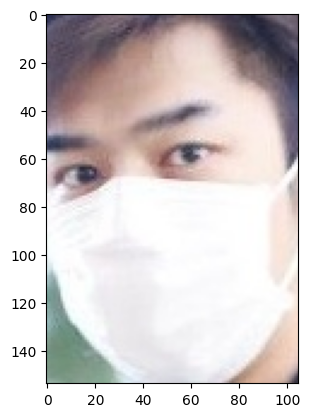

In [13]:
# displaying with mask images
img = mpimg.imread('D:/csv/archive (1)/data/with_mask/with_mask_259.jpg')
imgplot = plt.imshow(img)
plt.show()

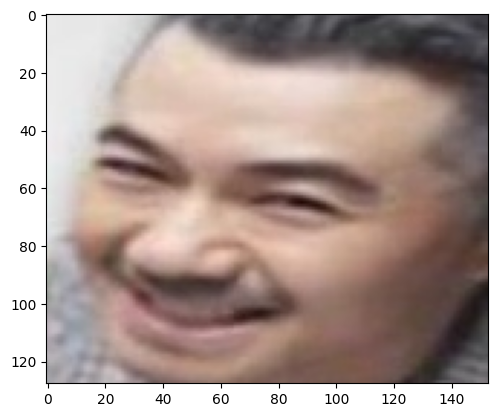

In [14]:
# displaying without mask images
img = mpimg.imread('D:/csv/archive (1)/data/without_mask/without_mask_200.jpg')
imgplot = plt.imshow(img)
plt.show()

### Image Processing

- resize images
- convert the images to numpy arrays

In [15]:
# convert images to numpy array

with_mask_path = r'D:\csv\archive (1)\data\with_mask/'
data = []
for img_file in with_mask_files:
    image = Image.open(with_mask_path + img_file) # open is for reading the image
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image) # create a tuple and resize the image to 128,128

without_mask_path = r'D:\csv\archive (1)\data\without_mask/'
for img_file in without_mask_files:
    image = Image.open(without_mask_path + img_file) # open is for reading the image
    image = image.resize((128,128))
    image = image.convert('RGB')
    image = np.array(image)
    data.append(image) # create a tuple and resize the image to 128,128



c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [16]:
type(data)

list

In [17]:
len(data)

7553

In [18]:
data[0]

array([[[50, 58, 31],
        [46, 55, 33],
        [56, 58, 42],
        ...,
        [27, 32, 25],
        [29, 33, 19],
        [33, 40, 17]],

       [[47, 54, 30],
        [49, 58, 36],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [37, 42, 31],
        [31, 41, 23]],

       [[51, 58, 37],
        [50, 59, 37],
        [59, 64, 37],
        ...,
        [45, 44, 30],
        [29, 34, 27],
        [20, 30, 18]],

       ...,

       [[63, 73, 37],
        [66, 75, 41],
        [74, 84, 50],
        ...,
        [ 5,  3,  0],
        [20, 19, 14],
        [17, 16, 12]],

       [[58, 72, 34],
        [60, 70, 39],
        [68, 75, 49],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 30],
        [53, 64, 37],
        [57, 64, 42],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [19, 12, 13]]], shape=(128, 128, 3), dtype=uint8)

In [19]:
type(data[0])

numpy.ndarray

In [38]:
data[1].shape

(128, 128, 3)

In [21]:
# converting image list and lable list to numpy array

X = np.array(data)
Y = np.array(labels)

In [22]:
type(X)

numpy.ndarray

In [23]:
type(Y)

numpy.ndarray

In [24]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [25]:
print(Y)

[1 1 1 ... 0 0 0]


Train Test Split

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=2)

In [27]:
print(X.shape,X_train.shape,X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [28]:
# scaling the data

X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [29]:
X_train[0]

array([[[226, 234, 201],
        [211, 216, 188],
        [188, 188, 169],
        ...,
        [186, 181, 165],
        [179, 175, 150],
        [166, 181, 136]],

       [[224, 228, 218],
        [201, 204, 195],
        [201, 199, 192],
        ...,
        [197, 190, 182],
        [175, 170, 153],
        [162, 180, 143]],

       [[205, 204, 212],
        [221, 220, 226],
        [195, 192, 196],
        ...,
        [183, 174, 173],
        [172, 167, 159],
        [181, 199, 171]],

       ...,

       [[156, 176, 197],
        [159, 180, 196],
        [164, 185, 196],
        ...,
        [ 89,  99,  71],
        [106, 113,  83],
        [ 99, 103,  68]],

       [[151, 177, 196],
        [167, 190, 208],
        [174, 192, 210],
        ...,
        [106, 113,  80],
        [ 99, 104,  64],
        [ 98,  98,  41]],

       [[162, 192, 210],
        [177, 199, 220],
        [175, 189, 213],
        ...,
        [103, 107,  70],
        [ 79,  80,  46],
        [ 99,  94,  61]]

In [30]:
X_test_scaled[0]

array([[[0.02745098, 0.00392157, 0.05882353],
        [0.03137255, 0.00784314, 0.0627451 ],
        [0.03529412, 0.01176471, 0.06666667],
        ...,
        [0.06666667, 0.01568627, 0.05098039],
        [0.0627451 , 0.01176471, 0.03921569],
        [0.05882353, 0.00784314, 0.03529412]],

       [[0.03529412, 0.00784314, 0.0627451 ],
        [0.03529412, 0.00784314, 0.0627451 ],
        [0.03529412, 0.01176471, 0.0627451 ],
        ...,
        [0.07058824, 0.01960784, 0.05098039],
        [0.06666667, 0.01568627, 0.04313725],
        [0.0627451 , 0.01176471, 0.04313725]],

       [[0.04313725, 0.00784314, 0.06666667],
        [0.03921569, 0.00784314, 0.0627451 ],
        [0.03529412, 0.00784314, 0.05882353],
        ...,
        [0.0745098 , 0.02352941, 0.05098039],
        [0.0745098 , 0.02352941, 0.05098039],
        [0.0745098 , 0.02352941, 0.05098039]],

       ...,

       [[0.93333333, 0.88627451, 0.70980392],
        [0.95294118, 0.90196078, 0.72941176],
        [0.98431373, 0

Building CNN

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D  

In [32]:
num_0f_classes = 2

model = Sequential()
model.add(Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3))) # 32 filters and 3x3 kernel size
model.add(MaxPooling2D(pool_size=(2, 2))) # max pooling layer with pool size of 2x2

model.add(Conv2D(64,(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))# fully connected layer with 128 neurons and relu activation function
model.add(Dropout(0.5)) # dropout layer with a dropout rate of 0.5

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_0f_classes, activation='sigmoid'))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# compile the NN model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [34]:
#training the model
history = model.fit(X_train_scaled, Y_train, validation_split=0.1,epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 29s 155ms/step - accuracy: 0.7914 - loss: 0.4705 - val_accuracy: 0.8860 - val_loss: 0.2559
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 27s 159ms/step - accuracy: 0.8884 - loss: 0.2982 - val_accuracy: 0.9157 - val_loss: 0.2293
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 150ms/step - accuracy: 0.9068 - loss: 0.2346 - val_accuracy: 0.9240 - val_loss: 0.2082
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 141ms/step - accuracy: 0.9119 - loss: 0.2163 - val_accuracy: 0.9240 - val_loss: 0.2412
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - accuracy: 0.9272 - loss: 0.1985 - val_accuracy: 0.9339 - val_loss: 0.2205
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 22s 130ms/step - accuracy: 0.9353 - loss: 0.1563 - val_accuracy: 0.9322 - val_loss: 0.2149
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 24s 140ms/step - accuracy: 0.9494 - loss: 0.1298 - val_accuracy: 0.9388 - val_loss: 0.2128
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 23s 136ms/step - accuracy: 0.9577 - loss: 0

### Model Evaluation


In [35]:
loss,accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test accuracy: ', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9239 - loss: 0.2294
Test accuracy:  0.9238914847373962


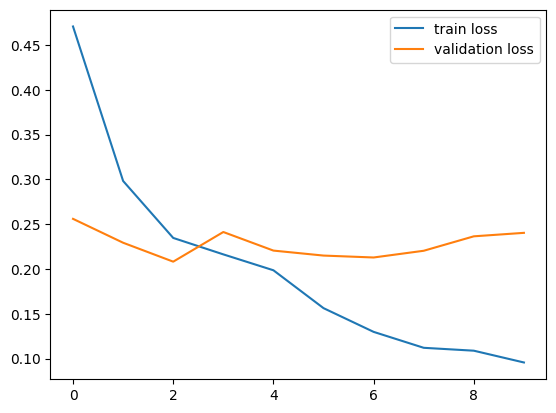

In [36]:
h = history

plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

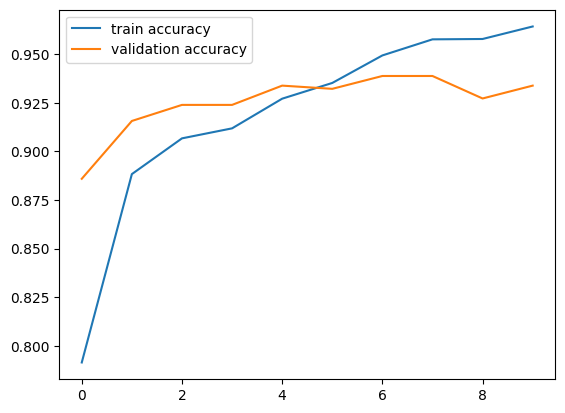

In [37]:
plt.plot(h.history['accuracy'], label='train accuracy')
plt.plot(h.history['val_accuracy'], label='validation accuracy')
plt.legend()
plt.show()